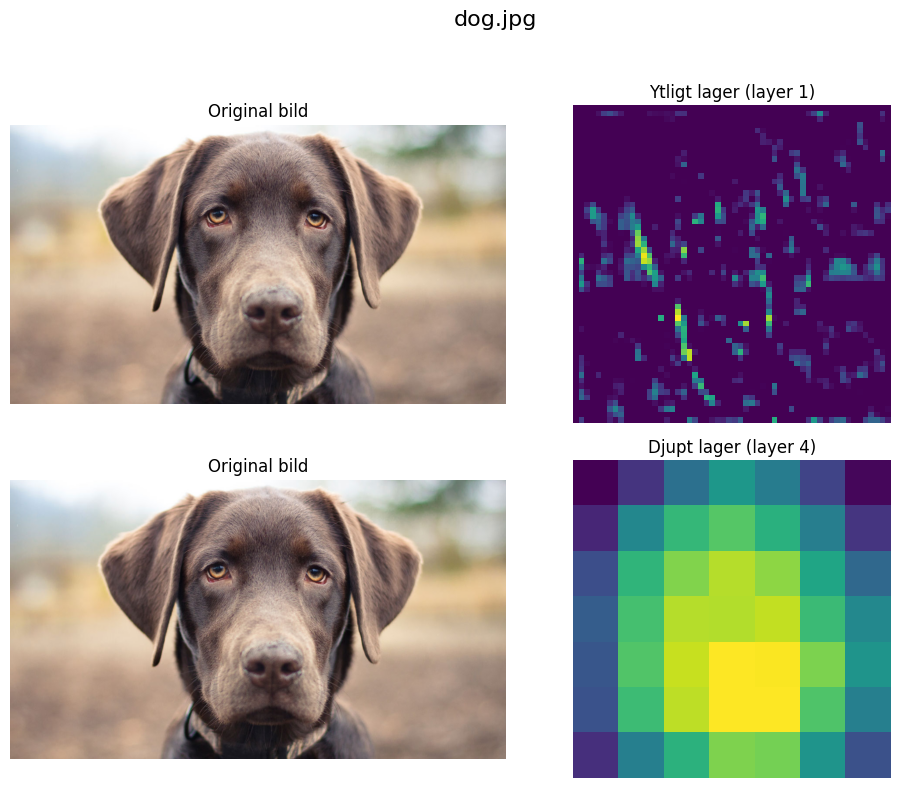

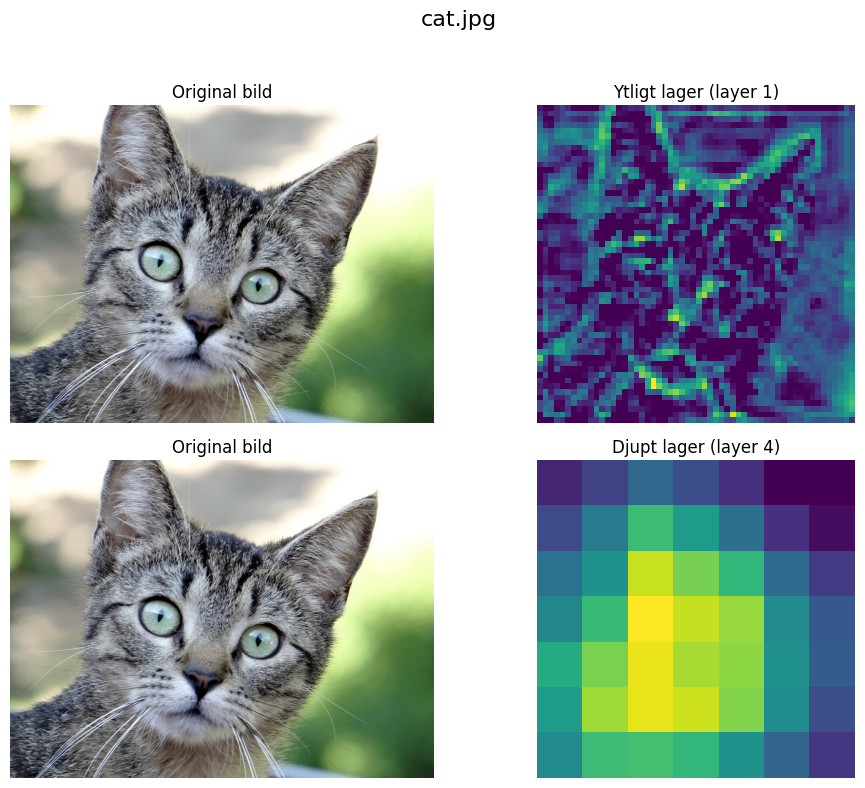

In [4]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from torchcam.methods import GradCAM

# Ladda förtränad modell
model = models.resnet18(pretrained=True)
model.eval()  # Modellen ska vara i eval-läge för att predikera

dog_image = "dog.jpg"
cat_image = "cat.jpg"

# Förbehandlar bilderna
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ändrar storlek
    transforms.ToTensor(),           # Gör om till tensor
    transforms.Normalize(            # Normaliserar
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Skapa Grad-CAM för två olika lager
cam_layer1 = GradCAM(model, target_layer="layer1")  # Ytligt lager
cam_layer4 = GradCAM(model, target_layer="layer4")  # Djupt lager

# Skala heatmaps
def normalize(cam):
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# Funktion som kör Grad-CAM och visar resultatet
def run_gradcam(image_path):
    img = Image.open(image_path).convert("RGB")       # Läser in bilden
    input_tensor = transform(img).unsqueeze(0)        # Förbehandling + batch-dimension

    # Tidigt lager (layer 1)
    scores_l1 = model(input_tensor)                   # Prediktion
    pred_class = scores_l1.argmax(dim=1).item()      # Predicerad klass
    cam1 = cam_layer1(class_idx=pred_class, scores=scores_l1)[0]
    cam1 = normalize(cam1.detach().cpu().squeeze().numpy())

    # Sent lager (layer 4)
    scores_l4 = model(input_tensor)
    cam4 = cam_layer4(class_idx=pred_class, scores=scores_l4)[0]
    cam4 = normalize(cam4.detach().cpu().squeeze().numpy())

    # Visa originalbilderna och heatmapsen
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    axs[0, 0].imshow(img)
    axs[0, 0].set_title("Original bild")
    axs[0, 0].axis("off")

    axs[0, 1].imshow(cam1, cmap="viridis")
    axs[0, 1].set_title("Ytligt lager (layer 1)")
    axs[0, 1].axis("off")

    axs[1, 0].imshow(img)
    axs[1, 0].set_title("Original bild")
    axs[1, 0].axis("off")

    axs[1, 1].imshow(cam4, cmap="viridis")
    axs[1, 1].set_title("Djupt lager (layer 4)")
    axs[1, 1].axis("off")

    plt.suptitle(f"{image_path}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Kör Grad-CAM på båda bilderna
run_gradcam(dog_image)
run_gradcam(cat_image)

## Inledning

I denna uppgift används Grad-CAM för att visualisera vilka delar av en bild som 
bidrar mest till modellens klassificeringsbeslut. En förtränad ResNet-18 används 
och två olika konvolutionslager visualiseras för att jämföra ytliga och djupa 
representationer.

## Resultat

Resultaten visar att aktiveringarna i det ytliga lagret (layer1) är mer utspridda 
och främst fokuserar på t.ex. kanter. I det djupa lagret (layer4) är aktiveringarna 
mer koncentrerade till de delar av objektet som är viktigast för att känna igen, 
som t.ex. huvudet i detta fallet. Det betyder att nätverket lär sig att förstå 
helheter i stället för enskilda detaljer ju djupare lagren är.

## Slutsats

Grad-CAM hjälper oss att se vilka delar av bilden som modellen använder när den tar 
ett beslut. Visualiseringarna visar också hur modellens fokus förändras från enkla 
detaljer i de ytliga lagren till mer betydelsefulla delar i de djupa lagren.